# 05 — Builds Table: Integration & Model B

Notebooks 02–04 told the **Model A** story: predict a car's *stock* 0–100 time from its
spec sheet, using only the `cars` table.

This notebook is about the project's actual goal — **Model B**: predict a car's
0–100 time *after modification*. That question needs all three tables joined together:

```
  builds  (what was modified, and the measured result)
    ⋈ cars          (the stock specs of that car)
    ⋈ modifications (what the mod typically does)
```

But before we can join, we have to confront the builds table's data-quality problems —
which are very different from the cars table's. This is where the messy reality of
combining data from multiple sources shows up.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

builds = pd.read_csv('../data/raw/builds_raw.csv')
cars   = pd.read_csv('../data/raw/cars_raw.csv')
mods   = pd.read_csv('../data/raw/modifications_raw.csv')

print(f"builds: {builds.shape[0]} rows")
print(f"cars:   {cars.shape[0]} rows")
print(f"mods:   {mods.shape[0]} rows")
builds.head(3)

builds: 372 rows
cars:   2150 rows
mods:   275 rows


,build_id,car_id,make,model,variant,year,mods_applied,mod_description,result_hp,result_torque,result_0_100,result_top_speed,result_quarter_mile,measurement_type,source_type,source_url,confidence
0,BUILD_6BD156C8,CAR_5256C2C6,VW,Golf GTI,Mk7 2.0 TSI IS20,2015.0,Stage 1 ECU;Intake,APR Stage 1 ECU remap + cold air intake,260.0,370.0,6.0,255.0,13.9,dyno,community,static_curated,0.75
1,BUILD_67DF6832,CAR_5256C2C6,VW,Golf GTI,Mk7 2.0 TSI IS20,2015.0,Stage 2 ECU;Intake;Downpipe;FMIC,APR Stage 2: ECU + intake + downpipe + front-m...,320.0,430.0,5.3,270.0,13.2,dyno,community,static_curated,0.75
2,BUILD_2D84249F,CAR_5256C2C6,VW,Golf GTI,Mk7 2.0 TSI IS20,2015.0,IS38 Turbo Upgrade;Stage 2 ECU;Intake;Downpipe...,IS38 swap + full Stage 2 supporting mods + DSG...,390.0,490.0,4.7,282.0,12.6,dyno,community,static_curated,0.75


---
## Step 1 — Source audit: where did each row come from?

The builds table was assembled from three very different sources. Unlike the cars table
(one source, Parkers), the builds rows have wildly different quality depending on origin.
The first thing to do is split by source and look at each.

In [2]:
print("Rows per source:")
print(builds['source_type'].value_counts().to_string())
print()

# Completeness of each result field, by source
result_cols = ['result_hp', 'result_torque', 'result_0_100',
               'result_top_speed', 'result_quarter_mile']
completeness = builds.groupby('source_type')[result_cols].apply(
    lambda g: (g.notna().sum() / len(g) * 100).round(0)
)
print("% of rows with each field present, by source:")
completeness

Rows per source:
source_type
synthetic    300
dragtimes     42
community     30

% of rows with each field present, by source:


,result_hp,result_torque,result_0_100,result_top_speed,result_quarter_mile
source_type,,,,,
community,100.0,100.0,100.0,100.0,100.0
dragtimes,10.0,7.0,100.0,0.0,100.0
synthetic,100.0,98.0,100.0,0.0,0.0


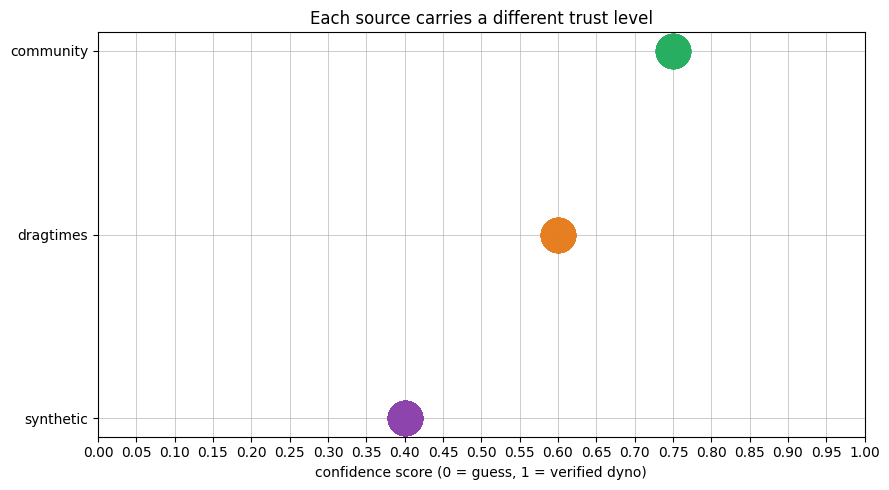

              min   max  mean
source_type                  
community    0.75  0.75  0.75
dragtimes    0.60  0.60  0.60
synthetic    0.40  0.40  0.40


In [3]:
# Confidence score distribution by source — our trust rating for each row
fig, ax = plt.subplots(figsize=(9, 5))
for src, color in [('synthetic', '#8e44ad'), ('dragtimes', '#e67e22'), ('community', '#27ae60')]:
    sub = builds[builds['source_type'] == src]
    ax.scatter(sub['confidence'], [src]*len(sub), alpha=0.3, s=600, color=color)
ax.set_xlabel('confidence score (0 = guess, 1 = verified dyno)')
ax.set_title('Each source carries a different trust level')
ax.set_xlim(0, 1)

# Make grid denser
ax.grid(True, which='major', alpha=0.9, linestyle='-', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.9, linestyle=':', linewidth=0.3)
ax.set_axisbelow(True)  # Put grid behind data points

# Set minor ticks for denser grid lines
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))  # Minor grid every 0.05
ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))   # Major grid every 0.1

plt.tight_layout()
plt.savefig('../docs/builds_confidence.png', dpi=120)
plt.show()

print(builds.groupby('source_type')['confidence'].agg(['min','max','mean']).round(2).to_string())

**Source audit findings:**

| Source | Rows | Character | Trust |
|--------|-----:|-----------|-------|
| `synthetic` | 300 | Physics-generated. Complete, clean, but not real observations. | 0.40 |
| `dragtimes` | 42 | Scraped from a drag-racing site. Has 1/4-mile times but rarely horsepower. | 0.60 |
| `community` | 30 | Hand-collected forum builds. Complete, but self-reported. | 0.75 |

Already a key insight: **completeness depends entirely on source.** `dragtimes` rows almost
never have horsepower; synthetic rows have everything. This is not random — it's the next
step's topic.

---
## Step 2 — Missingness is MAR (driven by source)

In notebook 03 we classified the cars table's missingness. Here the mechanism is obvious
and clean: whether `result_hp` is missing depends almost entirely on **which source** the
row came from. That's textbook **MAR** — missingness explained by an observed variable.

In [4]:
hp_missing_by_source = builds.groupby('source_type')['result_hp'].apply(
    lambda x: x.isna().mean() * 100
).round(0)
print("% of result_hp missing, by source:")
print(hp_missing_by_source.to_string())
print()
print("dragtimes is a drag-racing site: it records 1/4-mile times, not dyno horsepower.")
print("So the missingness is fully explained by source_type -> MAR, not MNAR.")
print("Implication: we can model with the rows that have hp, or impute knowing the source.")

% of result_hp missing, by source:
source_type
community     0.0
dragtimes    90.0
synthetic     0.0

dragtimes is a drag-racing site: it records 1/4-mile times, not dyno horsepower.
So the missingness is fully explained by source_type -> MAR, not MNAR.
Implication: we can model with the rows that have hp, or impute knowing the source.


---
## Step 3 — The integration problem: do the keys line up?

To join three tables we need **foreign keys** that match:
- `builds.car_id` must match `cars.car_id`
- `builds.mods_applied` must match `modifications.mod_id`

Let's check whether they actually do, by source.

In [5]:
car_ids = set(cars['car_id'])
mod_ids = set(mods['mod_id'])

rows = []
for src in ['synthetic', 'community', 'dragtimes']:
    sub = builds[builds['source_type'] == src]
    rows.append({
        'source': src,
        'rows': len(sub),
        'car_id present': sub['car_id'].notna().sum(),
        'car_id → cars ✓': sub['car_id'].isin(car_ids).sum(),
        'mods_applied → mods ✓': sub['mods_applied'].isin(mod_ids).sum(),
    })
link_audit = pd.DataFrame(rows)
print(link_audit.to_string(index=False))

   source  rows  car_id present  car_id → cars ✓  mods_applied → mods ✓
synthetic   300             300              300                    300
community    30              30                0                      0
dragtimes    42               0                0                      0


**The problem laid bare:**

- **Synthetic rows** link perfectly — by construction, they were *built from* the cars and
  mods tables, so their keys are valid.
- **Community rows** have a `car_id`, but it uses a *different hashing scheme* from the one
  in our cars table — so 0 of them match. Their `mods_applied` is free text
  ("Stage 1 ECU;Cold Air Intake"), not a `mod_id`.
- **Dragtimes rows** have no `car_id` at all.

So out of 72 **real** builds, **none** link to the cars table automatically. The only rows
that join cleanly are the synthetic ones. This is the classic **entity-resolution problem**:
the same real-world car is identified differently in different datasets.

---
## Step 4 — Entity resolution: try to recover the links

The real builds *do* have `make` and `model` as text. Can we match those to the cars table
to recover a link? Two obstacles:
1. **Naming inconsistency** — builds say "VW", cars say "Volkswagen"; builds say
   "Mercedes-Benz", cars say "Mercedes Benz".
2. **Genuinely absent cars** — many dragtimes entries (Tesla, Dodge, Chrysler, Jaguar) are
   American/niche models that simply aren't in our UK-market cars table.

We tackle (1) with a normalization map, then measure how many links we can recover.

In [6]:
# Normalize make names to the cars-table convention
MAKE_MAP = {
    'vw': 'Volkswagen',
    'mercedes': 'Mercedes Benz',
    'mercedes-benz': 'Mercedes Benz',
    'seat': 'Seat',
}

def normalize_make(m):
    if pd.isna(m):
        return m
    key = str(m).lower().strip()
    return MAKE_MAP.get(key, str(m).strip().title())

real = builds[builds['source_type'].isin(['community', 'dragtimes'])].copy()
real['make_norm'] = real['make'].apply(normalize_make)

cars_makes = set(cars['make'].str.strip())
real['make_in_cars'] = real['make_norm'].isin(cars_makes)

print("After make-name normalization — can the make be found in cars table?")
recovery = real.groupby('source_type')['make_in_cars'].agg(['sum', 'count'])
recovery.columns = ['make_matched', 'total']
print(recovery.to_string())
print()
print("Makes that still cannot be matched (genuinely absent from cars table):")
print(sorted(real.loc[~real['make_in_cars'], 'make_norm'].unique()))

After make-name normalization — can the make be found in cars table?
             make_matched  total
source_type                     
community              30     30
dragtimes              37     42

Makes that still cannot be matched (genuinely absent from cars table):
['Buell', 'Oldsmobile', 'Tesla']


Normalization recovers the make for the European builds (community forum cars: VW, Audi,
BMW, etc.), but the American drag-racing cars remain unmatchable because the underlying
model simply isn't in our UK-focused cars table.

**Honest conclusion:** entity resolution can partially repair the link, but not fully.
A complete fix would require expanding the cars table to cover those models — a
data-collection task, not a data-cleaning one. We document the gap rather than fake the link.

---
## Step 5 — The three-table JOIN

Now the core demonstration: **how three tables become one training table.**

We use the synthetic rows (the ones with valid keys) to show the mechanism cleanly.
Each build row gets enriched with its car's stock specs and its mod's typical gains —
producing one flat row per build that a model can learn from.

In [7]:
synth = builds[builds['source_type'] == 'synthetic'].copy()

# Columns we pull from each lookup table
car_cols = ['car_id', 'stock_hp', 'weight_kg', 'zero_hundred_stock',
            'engine_type', 'drivetrain']
mod_cols = ['mod_id', 'mod_name', 'mod_category',
            'typical_hp_gain_pct', 'typical_tq_gain_pct']

# JOIN 1: builds ⋈ cars  (on car_id)
joined = synth.merge(cars[car_cols], on='car_id', how='left', suffixes=('', '_car'))

# JOIN 2: ⋈ modifications  (builds.mods_applied = mods.mod_id)
joined = joined.merge(mods[mod_cols],
                      left_on='mods_applied', right_on='mod_id',
                      how='left', suffixes=('', '_mod'))

print(f"Synthetic builds: {len(synth)} rows")
print(f"After joining cars + mods: {len(joined)} rows × {joined.shape[1]} cols")
print()
# Show one fully-assembled training row
demo_cols = ['make', 'model', 'stock_hp', 'weight_kg', 'zero_hundred_stock',
             'mod_name', 'typical_hp_gain_pct', 'result_hp', 'result_0_100']
print("One assembled training row (3 tables → 1 row):")
joined[demo_cols].head(3).T

Synthetic builds: 300 rows
After joining cars + mods: 300 rows × 27 cols

One assembled training row (3 tables → 1 row):


,0,1,2
make,Audi,Audi,Audi
model,A6,A6,A6
stock_hp,591.0,591.0,591.0
weight_kg,2075.0,2075.0,2075.0
zero_hundred_stock,3.5,3.5,3.5
mod_name,Stage 1 ECU Remap — Petrol Turbo,Stage 2 ECU Remap — Petrol Turbo,Stage 3 ECU Remap — Petrol Turbo
typical_hp_gain_pct,18.0,32.0,55.0
result_hp,690.0,793.8,895.7
result_0_100,3.19,2.93,2.73


Read that row left to right: from `cars` we know the stock car (e.g. 220 hp, 1,400 kg,
stock 0–100 of 6.5 s). From `modifications` we know the mod applied (+32% hp). From
`builds` we have the measured outcome (`result_0_100`). The model's job: learn the mapping
from *stock specs + mod* → *post-mod time*.

---
## Step 6 — Model B

We engineer the same physics-informed features as Model A, but now for the *post-mod* state:
the modified horsepower, and the post-mod log power-to-weight ratio. Target: `result_0_100`.

In [8]:
d = joined.dropna(subset=['stock_hp', 'weight_kg', 'typical_hp_gain_pct', 'result_0_100']).copy()

# Post-mod horsepower implied by the stock hp and the mod's gain
d['modded_hp']        = d['stock_hp'] * (1 + d['typical_hp_gain_pct'] / 100)
d['modded_pwr_wt']    = d['modded_hp'] / d['weight_kg']
d['log_modded_pwr_wt'] = np.log(d['modded_pwr_wt'])

FEATURES_B = ['stock_hp', 'weight_kg', 'zero_hundred_stock',
              'typical_hp_gain_pct', 'modded_hp', 'log_modded_pwr_wt']
TARGET_B = 'result_0_100'

X, y = d[FEATURES_B].values, d[TARGET_B].values
model_b = LinearRegression()
cv_mae = -cross_val_score(model_b, X, y, cv=5, scoring='neg_mean_absolute_error').mean()
cv_r2  =  cross_val_score(model_b, X, y, cv=5, scoring='r2').mean()

print(f"Model B (trained on {len(d)} synthetic builds):")
print(f"  CV MAE = {cv_mae:.3f} sec")
print(f"  CV R²  = {cv_r2:.3f}")

Model B (trained on 300 synthetic builds):
  CV MAE = 0.097 sec
  CV R²  = 0.997


---
## Step 7 — The honest diagnosis: why that R² is a trap

Model B scores almost perfectly. **That is not a success — it is a warning sign**, and
recognising why is the most important data-centric-AI lesson in this notebook.

The synthetic `result_0_100` values were *generated* by the formula
$t_{mod} = t_{stock} \times (hp_{stock}/hp_{mod})^{0.6}$. When we then train a model using
`stock_hp`, `zero_hundred_stock`, and the hp gain as inputs, we are handing it the exact
ingredients of that formula. The model isn't *learning physics* — it's *reverse-engineering
our own equation*. High R² here measures self-consistency, not predictive power.

**Garbage-in, garbage-out works in reverse too:** formula-in, formula-out. A model can only
be as real as its training data. This is exactly the GIGO / data-centric principle from
Lab 1 — the model is a mirror of the data, and our data here is a mirror of a formula.

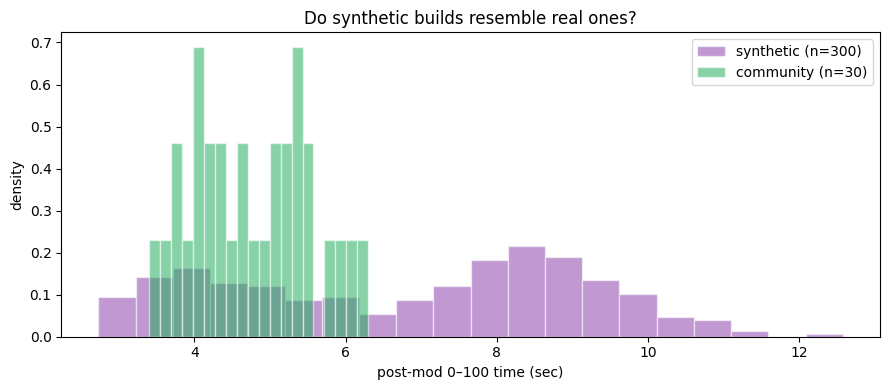

Synthetic vs community post-mod 0-100 (sec):
             mean   std   min    max
source_type                         
community    4.76  0.78  3.40   6.30
synthetic    6.83  2.32  2.73  12.58


In [9]:
# Reality check: do the synthetic outcomes even resemble the real ones?
# Compare the distribution of result_0_100 for synthetic vs real (community) builds.
fig, ax = plt.subplots(figsize=(9, 4))
for src, color in [('synthetic', '#8e44ad'), ('community', '#27ae60')]:
    vals = builds.loc[builds['source_type'] == src, 'result_0_100'].dropna()
    ax.hist(vals, bins=20, alpha=0.55, label=f'{src} (n={len(vals)})',
            color=color, edgecolor='white', density=True)
ax.set_xlabel('post-mod 0–100 time (sec)')
ax.set_ylabel('density')
ax.set_title('Do synthetic builds resemble real ones?')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/synthetic_vs_real_builds.png', dpi=120)
plt.show()

print("Synthetic vs community post-mod 0-100 (sec):")
print(builds[builds['source_type'].isin(['synthetic','community'])]
      .groupby('source_type')['result_0_100'].describe()[['mean','std','min','max']].round(2).to_string())

---
## Summary — what notebook 05 establishes

1. **Multi-source data is messy in ways single-source data isn't.** Completeness, trust, and
   even ID schemes differ by source. We audited each separately rather than treating the
   builds table as one uniform thing.
2. **Missingness here is cleanly MAR** — `result_hp` is missing precisely because dragtimes
   is a drag-racing site that doesn't record dyno power.
3. **Joining real-world datasets requires entity resolution.** Foreign keys didn't line up;
   make-name normalization recovered the European builds but the American drag cars remain
   genuinely absent from the cars table.
4. **The three-table JOIN works** and produces a proper flat training table — the mechanism
   behind "how a model learns from three tables."
5. **Model B is a pipeline proof-of-concept, not a validated predictor.** Its near-perfect
   score is an artefact of training on formula-generated data. Real validation needs more
   real builds — which is the project's central data-collection challenge going forward.

**This is the honest framing for the presentation:** Model A demonstrates the full
data-preparation journey on real data; Model B demonstrates the *architecture* of the
intended system and, just as importantly, demonstrates that we understand the limits of
synthetic data.